# 3. Machine Learning for Classification

We'll use logistic regression to predict churn


## 3.1 Churn prediction project

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/Telco-Customer-Churn.csv


## 3.2 Data preparation

* Download the data, read it with pandas
* Look at the data
* Make column names and values look uniform
* Check if all the columns read correctly
* Check if the churn variable needs any preparation

In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [4]:
data = 'https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/Telco-Customer-Churn.csv'

In [5]:
!wget $data -O Telco-Customer-Churn.csv

--2026-02-22 14:41:16--  https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: 'Telco-Customer-Churn.csv'

Telco-Customer-Chur 100%[===================>] 947.71K   247KB/s    in 3.8s    

2026-02-22 14:41:22 (247 KB/s) - 'Telco-Customer-Churn.csv' saved [970457/970457]



In [6]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# 
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [8]:
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
# Transpose the DataFrame to view columns as rows
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,9305-CDSKC,1452-KIOVK,6713-OKOMC,7892-POOKP,6388-TABGU
gender,Female,Male,Male,Male,Female,Female,Male,Female,Female,Male
seniorcitizen,0,0,0,0,0,0,0,0,0,0
partner,Yes,No,No,No,No,No,No,No,Yes,No
dependents,No,No,No,No,No,No,Yes,No,No,Yes
tenure,1,34,2,45,2,8,22,10,28,62
phoneservice,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes
multiplelines,No phone service,No,No,No phone service,No,Yes,Yes,No phone service,Yes,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,DSL,Fiber optic,DSL
onlinesecurity,No,Yes,Yes,Yes,No,No,No,Yes,No,Yes


In [10]:
df.totalcharges.isnull().sum()

np.int64(0)

In [11]:
pd.to_numeric(df.totalcharges)

ValueError: Unable to parse string " " at position 488

In [ ]:
# Convert 'totalcharges' to numeric, coercing errors to NaN
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [ ]:
tc.isnull().sum()

np.int64(11)

In [ ]:
df[tc.isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
df[tc.isnull()][['customerid','totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [ ]:
df.totalcharges

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: totalcharges, Length: 7043, dtype: str

In [ ]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [ ]:
df[df.totalcharges.isnull()][['customerid','totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,NaN
753,3115-CZMZD,NaN
936,5709-LVOEQ,NaN
1082,4367-NUYAO,NaN
1340,1371-DWPAZ,NaN
3331,7644-OMVMY,NaN
3826,3213-VVOLG,NaN
4380,2520-SGTTA,NaN
5218,2923-ARZLG,NaN
6670,4075-WKNIU,NaN


In [ ]:
df.totalcharges = df.totalcharges.fillna(0)

In [ ]:
df[df.totalcharges.isnull()][['customerid','totalcharges']]

,customerid,totalcharges


In [ ]:
df.churn.head(10)

0     No
1     No
2    Yes
3     No
4    Yes
5    Yes
6     No
7     No
8    Yes
9     No
Name: churn, dtype: str

In [83]:
df.churn

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7043, dtype: str

In [ ]:
# Convert churn column to binary, where 'Yes' becomes 1 and 'No' becomes 0
(df.churn == 'Yes').astype(int).head(10)

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: churn, dtype: int64

In [ ]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [86]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [ ]:
df.churn = (df.churn == 'Yes').astype(int)

In [ ]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [ ]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,9305-CDSKC,1452-KIOVK,6713-OKOMC,7892-POOKP,6388-TABGU
gender,Female,Male,Male,Male,Female,Female,Male,Female,Female,Male
seniorcitizen,0,0,0,0,0,0,0,0,0,0
partner,Yes,No,No,No,No,No,No,No,Yes,No
dependents,No,No,No,No,No,No,Yes,No,No,Yes
tenure,1,34,2,45,2,8,22,10,28,62
phoneservice,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes
multiplelines,No phone service,No,No,No phone service,No,Yes,Yes,No phone service,Yes,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,DSL,Fiber optic,DSL
onlinesecurity,No,Yes,Yes,Yes,No,No,No,Yes,No,Yes


## 3.3 Setting up the validation framework

* Perform the train/validation/test split with Scikit-Learn

In [14]:
# Import necessary libraries for model training and evaluation
from sklearn.model_selection import train_test_split

In [15]:
# Split the data into training, validation, and test sets
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [16]:
df_full_train.churn.value_counts()

churn
No     4113
Yes    1521
Name: count, dtype: int64

In [17]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [18]:
# Check the sizes of the splits
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [19]:
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
3897,8015-IHCGW,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.50,8425.15,No
1980,1960-UYCNN,Male,0,No,No,10,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,95.25,1021.55,No
6302,9250-WYPLL,Female,0,No,No,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,75.55,413.65,Yes
727,6786-OBWQR,Female,0,Yes,Yes,5,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.85,356.1,No
5104,1328-EUZHC,Female,0,Yes,No,18,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.10,370.5,No


In [20]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [21]:
df_train.head().T

,0,1,2,3,4
customerid,8015-IHCGW,1960-UYCNN,9250-WYPLL,6786-OBWQR,1328-EUZHC
gender,Female,Male,Female,Female,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,Yes,Yes
dependents,Yes,No,No,Yes,No
tenure,72,10,5,5,18
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,Yes,Yes,Yes,No,No
internetservice,Fiber optic,Fiber optic,Fiber optic,Fiber optic,No
onlinesecurity,Yes,No,No,No,No internet service


In [22]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [23]:
df_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,8015-IHCGW,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.50,8425.15,No
1,1960-UYCNN,Male,0,No,No,10,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,95.25,1021.55,No
2,9250-WYPLL,Female,0,No,No,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,75.55,413.65,Yes
3,6786-OBWQR,Female,0,Yes,Yes,5,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.85,356.1,No
4,1328-EUZHC,Female,0,Yes,No,18,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.10,370.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,1309-XGFSN,Male,1,Yes,Yes,52,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,80.85,4079.55,No
4221,4819-HJPIW,Male,0,No,No,18,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,25.15,476.8,No
4222,3703-VAVCL,Male,0,Yes,Yes,2,Yes,No,Fiber optic,No,...,Yes,Yes,No,Yes,Month-to-month,No,Credit card (automatic),90.00,190.05,Yes
4223,3812-LRZIR,Female,0,Yes,Yes,27,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.50,761.95,No


In [24]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [25]:
df_train.head().T

,0,1,2,3,4
customerid,8015-IHCGW,1960-UYCNN,9250-WYPLL,6786-OBWQR,1328-EUZHC
gender,Female,Male,Female,Female,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,Yes,Yes
dependents,Yes,No,No,Yes,No
tenure,72,10,5,5,18
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,Yes,Yes,Yes,No,No
internetservice,Fiber optic,Fiber optic,Fiber optic,Fiber optic,No
onlinesecurity,Yes,No,No,No,No internet service


## 3.4 EDA

* Check missing values
* Look at the target variable (churn)
* Look at numerical and categorical variables

In [26]:
len(df_full_train)

5634

In [27]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,No
5946,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,Yes
3881,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,No
2389,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,No
3676,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,No


In [28]:
df_full_train = df_full_train.reset_index(drop=True)

In [29]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,No
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,Yes
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,No
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,No
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.6,Yes
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.9,No
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.5,Yes
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.1,Yes


In [30]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [31]:
df_full_train.churn.value_counts(normalize=True)

churn
No     0.730032
Yes    0.269968
Name: proportion, dtype: float64

In [34]:
df_full_train.churn = (df.churn == 'Yes').astype(int)

In [36]:
df_full_train.churn.mean()

np.float64(0.2641107561235357)

In [38]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [39]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [40]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [41]:
df_full_train[categorical].head(10).T

,0,1,2,3,4,5,6,7,8,9
gender,Male,Female,Male,Male,Male,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0,0,0,0,1,1
partner,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes
dependents,Yes,No,No,Yes,No,Yes,No,No,No,Yes
phoneservice,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
multiplelines,No,No,Yes,Yes,No,No,Yes,No,Yes,No
internetservice,No,DSL,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,Fiber optic
onlinesecurity,No internet service,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No
onlinebackup,No internet service,Yes,Yes,No,Yes,Yes,Yes,No,No,No
deviceprotection,No internet service,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No


## 3.5 Feature importance: Churn rate and risk ratio

Feature importance analysis (part of EDA) - identifying which features affect our target variable

* Churn rate
* Risk ratio
* Mutual information - later

#### Churn rate

In [44]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,0
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,1
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.6,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.9,1
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.5,0
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.1,0


In [87]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.2641107561235357)

In [88]:
churn_female = df_full_train[df_full_train.gender == 'Female'].churn.mean()
churn_female

np.float64(0.2657367668097282)

In [90]:
global_churn - churn_female

np.float64(-0.0016260106861925028)

In [91]:
churn_male = df_full_train[df_full_train.gender == 'Male'].churn.mean()
churn_male

np.float64(0.26250880902043694)

In [92]:
global_churn - churn_male

np.float64(0.0016019471030987442)

In [50]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [51]:
df_full_train.partner

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
5629     No
5630     No
5631     No
5632     No
5633    Yes
Name: partner, Length: 5634, dtype: str

In [93]:
churn_partner = df_full_train[df_full_train.partner == 'Yes'].churn.mean()
churn_partner

np.float64(0.2561065877128053)

In [94]:
global_churn - churn_partner

np.float64(0.008004168410730372)

In [95]:
churn_no_partner = df_full_train[df_full_train.partner == 'No'].churn.mean()
churn_no_partner

np.float64(0.27148703956343795)

In [96]:
global_churn - churn_no_partner

np.float64(-0.007376283439902265)

#### Risk ratio

In [57]:
global_churn, churn_no_partner

(np.float64(0.2641107561235357), np.float64(0.27148703956343795))

In [58]:
churn_no_partner / global_churn

np.float64(1.0279287506051138)

In [59]:
churn_partner / global_churn

np.float64(0.9696938946061459)

In [60]:
from IPython.display import display

In [61]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [62]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()

gender


,mean,count,diff,risk
gender,,,,
Female,0.265737,2796,0.001626,1.006157
Male,0.262509,2838,-0.001602,0.993935



seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.267260,4722,0.003149,1.011923
1,0.247807,912,-0.016304,0.938269



partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.261598,3104,-0.002513,0.990486
One year,0.261383,1186,-0.002728,0.989671
Two year,0.272321,1344,0.008211,1.031088



paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.281453,2313,0.017342,1.065661
Yes,0.252033,3321,-0.012078,0.954268



paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.244463,1219,-0.019648,0.925607
Credit card (automatic),0.266228,1217,0.002118,1.008018
Electronic check,0.260433,1893,-0.003678,0.986076
Mailed check,0.285824,1305,0.021713,1.082212


## 3.6 Feature importance: Mutual information

Mutual information - concept from information theory, it tells us how much
we can learn about one variable if we know the value of another

* https://en.wikipedia.org/wiki/Mutual_information

In [69]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,0
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,1
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.6,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.9,1
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.5,0
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.1,0


In [64]:
from sklearn.metrics import mutual_info_score

In [70]:
df.contract

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7038          One year
7039          One year
7040    Month-to-month
7041    Month-to-month
7042          Two year
Name: contract, Length: 7043, dtype: str

In [71]:
df.churn

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7043, dtype: str

In [82]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,0
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,1
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,1


In [73]:
mutual_info_score(df.churn, df.contract)

0.09845305342598942

In [74]:
mutual_info_score(df.gender, df.churn)

3.7082914405128786e-05

In [75]:
mutual_info_score(df.contract, df.churn)

0.09845305342598942

In [76]:
mutual_info_score(df.partner, df.churn)

0.011453657253317984

In [77]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df.churn)

In [78]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [80]:
df.churn

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7043, dtype: str

In [79]:
mi = df[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098453
onlinesecurity      0.064677
techsupport         0.063021
internetservice     0.055574
onlinebackup        0.046792
paymentmethod       0.044519
deviceprotection    0.043917
streamingmovies     0.032001
streamingtv         0.031908
paperlessbilling    0.019194
dependents          0.014467
partner             0.011454
seniorcitizen       0.010577
multiplelines       0.000801
phoneservice        0.000072
gender              0.000037
dtype: float64

## 3.7 Feature importance: Correlation

How about numerical columns?

* Correlation coefficient - https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

In [ ]:
df_full_train.tenure.max()

72

In [ ]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

,0
tenure,0.351885
monthlycharges,0.196805
totalcharges,0.196353


In [ ]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [ ]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [ ]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [ ]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [ ]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [ ]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

## 3.8 One-hot encoding

* Use Scikit-Learn to encode categorical features

In [ ]:
from sklearn.feature_extraction import DictVectorizer

In [ ]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

## 3.9 Logistic regression

* Binary classification
* Linear vs logistic regression

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
z = np.linspace(-7, 7, 51)

In [ ]:
sigmoid(10000)

np.float64(1.0)

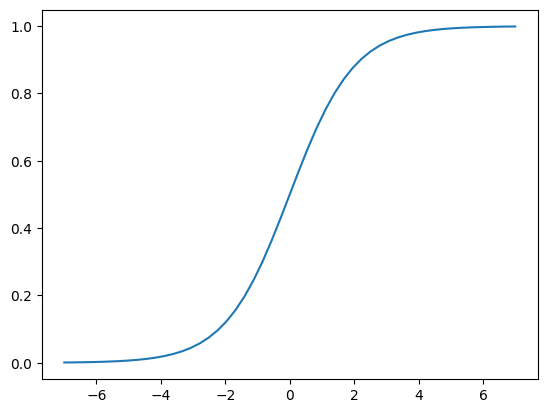

In [ ]:
plt.plot(z, sigmoid(z))

In [ ]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]

    return result

In [ ]:
def logistic_regression(xi):
    score = w0

    for j in range(len(w)):
        score = score + xi[j] * w[j]

    result = sigmoid(score)
    return result

## 3.10 Training logistic regression with Scikit-Learn

* Train a model with Scikit-Learn
* Apply it to the validation dataset
* Calculate the accuracy

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(solver='lbfgs')
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
model.coef_[0]

array([ 4.80642158e-01, -1.71996646e-01, -4.43453845e-01, -5.22061574e-02,
       -8.26021759e-02,  4.38471995e-02, -1.02965714e-01, -7.56898188e-02,
       -4.92624933e-02, -8.55458401e-02, -3.47131222e-01,  3.15288603e-01,
       -1.02965714e-01,  4.41947926e-03, -2.13551545e-01,  9.75753100e-02,
       -1.88320985e-02,  9.49656070e-02, -1.02965714e-01, -1.26808226e-01,
        2.06350702e-01, -1.02965714e-01, -2.38193322e-01, -2.11398706e-01,
        7.65903722e-02, -1.30623901e-01, -4.18443204e-03, -9.80091788e-02,
       -1.20323866e-01,  2.28368720e-01, -1.44844009e-01,  9.75753100e-02,
       -2.32383643e-01,  2.07841218e-01, -1.38600272e-01, -1.02965714e-01,
        1.06757653e-01, -7.43898311e-02, -1.02965714e-01,  4.25472118e-02,
        2.05372697e-01, -1.02965714e-01, -2.37215316e-01, -6.21423231e-02,
        3.16549571e-04])

In [ ]:
model.coef_[0].round(2)

array([ 0.48, -0.17, -0.44, -0.05, -0.08,  0.04, -0.1 , -0.08, -0.05,
       -0.09, -0.35,  0.32, -0.1 ,  0.  , -0.21,  0.1 , -0.02,  0.09,
       -0.1 , -0.13,  0.21, -0.1 , -0.24, -0.21,  0.08, -0.13, -0.  ,
       -0.1 , -0.12,  0.23, -0.14,  0.1 , -0.23,  0.21, -0.14, -0.1 ,
        0.11, -0.07, -0.1 ,  0.04,  0.21, -0.1 , -0.24, -0.06,  0.  ])

In [ ]:
model.intercept_[0]

np.float64(-0.13607674189525867)

In [ ]:
model.coef_[0].round(3)

array([ 0.564, -0.154, -0.519, -0.013, -0.095,  0.071, -0.098, -0.082,
       -0.033, -0.076, -0.354,  0.343, -0.098,  0.002, -0.251,  0.162,
       -0.02 ,  0.066, -0.098, -0.076,  0.251, -0.098, -0.261, -0.228,
        0.119, -0.121,  0.012, -0.095, -0.03 ,  0.045, -0.028,  0.162,
       -0.271,  0.221, -0.097, -0.098,  0.087, -0.05 , -0.098,  0.039,
        0.194, -0.098, -0.205, -0.072,  0.   ])

In [ ]:
y_pred = model.predict_proba(X_val)[:, 1]

In [ ]:
churn_decision = (y_pred >= 0.5)

In [ ]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

In [ ]:
y_val

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [ ]:
df_pred

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True
...,...,...,...,...
1404,0.297790,0,0,True
1405,0.035463,0,1,False
1406,0.150149,0,0,True
1407,0.776681,1,1,True


In [ ]:
df_pred.actual

,actual
0,0
1,0
2,0
3,1
4,0
...,...
1404,0
1405,1
1406,0
1407,1


In [ ]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [ ]:
df_val[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
12,7228-omtpn,male,0,no,no,4,yes,no,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,electronic_check,88.45,370.65
30,3074-gqwyx,male,0,no,no,5,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,yes,bank_transfer_(automatic),75.90,357.75
35,3859-cvcet,female,0,no,no,4,yes,no,dsl,no,no,no,no,no,no,month-to-month,no,mailed_check,45.65,191.05
37,9396-zsfll,female,0,no,no,15,yes,yes,dsl,no,no,no,no,no,no,month-to-month,no,mailed_check,48.85,631.40
42,2230-xtuwl,female,0,yes,yes,48,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.55,883.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1392,0319-qztco,female,0,yes,yes,3,yes,no,dsl,no,yes,no,no,yes,no,month-to-month,yes,credit_card_(automatic),58.70,168.60
1395,5366-obvmr,female,0,yes,no,18,yes,no,dsl,no,no,no,yes,no,no,month-to-month,yes,mailed_check,50.30,908.75
1403,8879-xuahx,male,0,yes,no,71,yes,yes,fiber_optic,yes,yes,yes,yes,yes,yes,two_year,yes,electronic_check,116.25,8564.75
1404,0980-pvmrc,female,0,yes,yes,40,no,no_phone_service,dsl,no,yes,no,no,yes,yes,month-to-month,yes,electronic_check,50.85,2036.55


In [ ]:
df_pred.correct.mean()

np.float64(0.801277501774308)

In [ ]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1])

## 3.11 Model interpretation

* Look at the coefficients
* Train a smaller model with fewer features

In [ ]:
a = [1, 2, 3, 4]
b = 'abcd'

In [ ]:
list(zip(a, b))

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]

In [ ]:
dict(zip(a, b))

{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [ ]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [ ]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.481),
 'contract=one_year': np.float64(-0.172),
 'contract=two_year': np.float64(-0.443),
 'dependents=no': np.float64(-0.052),
 'dependents=yes': np.float64(-0.083),
 'deviceprotection=no': np.float64(0.044),
 'deviceprotection=no_internet_service': np.float64(-0.103),
 'deviceprotection=yes': np.float64(-0.076),
 'gender=female': np.float64(-0.049),
 'gender=male': np.float64(-0.086),
 'internetservice=dsl': np.float64(-0.347),
 'internetservice=fiber_optic': np.float64(0.315),
 'internetservice=no': np.float64(-0.103),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.214),
 'multiplelines=no_phone_service': np.float64(0.098),
 'multiplelines=yes': np.float64(-0.019),
 'onlinebackup=no': np.float64(0.095),
 'onlinebackup=no_internet_service': np.float64(-0.103),
 'onlinebackup=yes': np.float64(-0.127),
 'onlinesecurity=no': np.float64(0.206),
 'onlinesecurity=no_internet_service': np.float64(-0.103),
 'onlinesecurity=ye

In [ ]:
small = ['contract', 'tenure', 'monthlycharges']
small

['contract', 'tenure', 'monthlycharges']

In [ ]:
df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10
5,month-to-month,4,30.50
6,month-to-month,1,75.10
7,month-to-month,1,70.30
8,two_year,72,19.75
9,month-to-month,6,109.90


In [ ]:
df_val[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,71,70.85
1,month-to-month,1,20.75
2,month-to-month,1,20.35
3,month-to-month,2,75.70
4,month-to-month,1,19.90
5,month-to-month,16,49.45
6,one_year,39,41.15
7,two_year,68,25.75
8,month-to-month,6,99.95
9,month-to-month,1,45.70


In [ ]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [ ]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [ ]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [ ]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [ ]:
dicts_train_small

In [ ]:
X_train_small = dv_small.transform(dicts_train_small)
X_train_small

array([[  0.  ,   0.  ,   1.  , 115.5 ,  72.  ],
       [  1.  ,   0.  ,   0.  ,  95.25,  10.  ],
       [  1.  ,   0.  ,   0.  ,  75.55,   5.  ],
       ...,
       [  1.  ,   0.  ,   0.  ,  90.  ,   2.  ],
       [  0.  ,   0.  ,   1.  ,  24.5 ,  27.  ],
       [  1.  ,   0.  ,   0.  ,  80.85,   9.  ]])

In [ ]:
model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

LogisticRegression()

In [ ]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957595829565)

In [ ]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [ ]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [ ]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [ ]:
sigmoid(_)

np.float64(0.030090303318277657)

In [ ]:
df_full_train.churn.values

array([0, 1, 0, ..., 1, 1, 0])

In [ ]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [ ]:
numerical

['tenure', 'monthlycharges', 'totalcharges']

## 3.12 Using the model

In [ ]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')
dicts_full_train

In [ ]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [ ]:
y_full_train = df_full_train.churn.values
y_full_train

array([0, 1, 0, ..., 1, 1, 0])

In [ ]:
X_full_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 2.58350e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.20000e+01, 3.16055e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 4.68175e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.80000e+01, 2.97950e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.00000e+00, 1.14100e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        1.60000e+01, 1.11485e+03]])

In [ ]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
dicts_test

In [ ]:
X_test = dv.transform(dicts_test)
X_test

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.10000e+01, 3.32075e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.60000e+01, 6.47185e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 5.24350e+02],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 3.88865e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        6.50000e+01, 5.68845e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.70000e+01, 1.74350e+03]])

In [ ]:
y_pred = model.predict_proba(X_test)[: , 1]
y_pred

array([0.05704183, 0.12942998, 0.32184304, ..., 0.00652234, 0.19165844,
       0.66134701])

In [ ]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False, False,  True])

In [ ]:
(churn_decision == y_test).mean()

np.float64(0.8140525195173882)

In [ ]:
y_test

array([0, 0, 0, ..., 0, 0, 1])

In [ ]:
customer = dicts_test[-1]
customer

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [ ]:
X_small = dv.transform([customer])

In [ ]:
model.predict_proba(X_small)[0, 1]

np.float64(0.6613470087309817)

In [ ]:
y_test[-1]

np.int64(1)

## 3.13 Summary

* Feature importance - risk, mutual information, correlation
* One-hot encoding can be implemented with `DictVectorizer`
* Logistic regression - linear model like linear regression
* Output of log reg - probability
* Interpretation of weights is similar to linear regression

## 3.14 Explore more

More things

* Try to exclude least useful features


Use scikit-learn in project of last week

* Re-implement train/val/test split using scikit-learn in the project from the last week
* Also, instead of our own linear regression, use `LinearRegression` (not regularized) and `RidgeRegression` (regularized). Find the best regularization parameter for Ridge

Other projects

* Lead scoring - https://www.kaggle.com/ashydv/leads-dataset
* Default prediction - https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

